# Capítulo 29 — Sesgos, datos y decisiones

Un modelo no aprende desde una realidad completa: aprende desde datos producidos por procesos concretos. En este cuaderno retomaremos explícitamente el ejemplo educativo del capítulo teórico. Trabajaremos con actividad registrada en una plataforma, conectividad, dispositivos compartidos y una tarea de identificación de estudiantes que podrían necesitar apoyo.

El conjunto será **sintético**. Esto nos permitirá conocer cómo fue construido y preparar problemas que en datos reales suelen ser difíciles de observar: subrepresentación, faltantes concentrados, etiquetas históricas imperfectas y variables que funcionan como proxies.

El propósito no será construir un sistema para decidir sobre estudiantes. Usaremos el modelo como objeto de auditoría para aprender qué preguntas debemos hacer antes de confiar en una predicción.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- reconocer que un dataset representa un proceso de recolección;
- comparar la representación de grupos entre entrenamiento y aplicación;
- comprobar si los faltantes se distribuyen de manera desigual;
- explicar por qué eliminar filas puede intensificar una subrepresentación;
- distinguir una necesidad simulada de una decisión histórica registrada;
- reservar una variable sensible o contextual para auditar;
- reconocer variables que pueden actuar como proxies;
- evaluar accuracy, precision, recall, F1 y tasa de falsos positivos por subgrupo;
- observar cómo la muestra de entrenamiento modifica los resultados;
- analizar el efecto del umbral sobre errores y cantidad de revisiones;
- diferenciar asociación predictiva de causalidad;
- documentar límites y mantener responsabilidad humana sobre las decisiones.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para construir y analizar los datos, Matplotlib para visualizar y herramientas de `scikit-learn` para preprocesar, entrenar y evaluar una regresión logística.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Construir una población educativa sintética

La variable `necesita_apoyo` se generará principalmente a partir de una preparación académica latente y de una carga externa simulada. La conectividad no participará directamente en esa definición.

En cambio, la conectividad limitada y el uso de un dispositivo compartido reducirán la **actividad que logra registrar la plataforma**. Así podremos observar un problema central del capítulo: baja actividad registrada no equivale necesariamente a poco compromiso o a mayor dificultad.


In [2]:
generador = np.random.default_rng(29)
cantidad_estudiantes = 9_000

acceso_limitado = generador.binomial(1, 0.25, cantidad_estudiantes)
dispositivo_compartido = generador.binomial(
    1,
    np.where(acceso_limitado == 1, 0.65, 0.10),
)
uso_movil = generador.binomial(
    1,
    np.where(acceso_limitado == 1, 0.58, 0.14),
)

compromiso = generador.normal(0, 1, cantidad_estudiantes)
preparacion = generador.normal(0, 1, cantidad_estudiantes)
carga_externa = generador.normal(0, 1, cantidad_estudiantes)

puntaje_necesidad = (
    -0.70
    - 1.25 * preparacion
    + 0.45 * carga_externa
    + generador.normal(0, 0.60, cantidad_estudiantes)
)
probabilidad_necesidad = 1 / (1 + np.exp(-puntaje_necesidad))
necesita_apoyo = generador.binomial(1, probabilidad_necesidad)

puntaje_diagnostico = np.clip(
    70 + 12 * preparacion
    + generador.normal(0, 5, cantidad_estudiantes),
    20,
    100,
)
promedio_previo = np.clip(
    7 + 1.2 * preparacion - 0.45 * necesita_apoyo
    + generador.normal(0, 0.70, cantidad_estudiantes),
    1,
    10,
)
faltas = np.clip(
    generador.poisson(
        np.exp(0.65 + 0.35 * carga_externa + 0.30 * necesita_apoyo)
    ),
    0,
    25,
)

accesos_semana = np.clip(
    np.rint(
        12
        + 2.2 * compromiso
        - 4.5 * acceso_limitado
        - 2.0 * dispositivo_compartido
        - 3.0 * necesita_apoyo
        + generador.normal(0, 2.3, cantidad_estudiantes)
    ),
    0,
    25,
)
tiempo_plataforma = np.clip(
    260
    + 45 * compromiso
    - 95 * acceso_limitado
    - 45 * dispositivo_compartido
    - 65 * necesita_apoyo
    + generador.normal(0, 45, cantidad_estudiantes),
    0,
    600,
)
actividades_entregadas = np.clip(
    np.rint(
        8
        + 1.1 * compromiso
        - 0.8 * acceso_limitado
        - 0.4 * dispositivo_compartido
        - 1.5 * necesita_apoyo
        + generador.normal(0, 1.2, cantidad_estudiantes)
    ),
    0,
    10,
)
participaciones_foro = np.clip(
    generador.poisson(
        np.exp(
            0.25
            + 0.25 * compromiso
            - 0.40 * acceso_limitado
            - 0.25 * necesita_apoyo
        )
    ),
    0,
    12,
)

estudiantes = pd.DataFrame({
    "puntaje_diagnostico": puntaje_diagnostico.round(1),
    "promedio_previo": promedio_previo.round(2),
    "faltas": faltas,
    "accesos_semana": accesos_semana.astype(int),
    "tiempo_plataforma_min": tiempo_plataforma.round(1),
    "actividades_entregadas": actividades_entregadas.astype(int),
    "participaciones_foro": participaciones_foro,
    "dispositivo_compartido": np.where(
        dispositivo_compartido == 1, "Si", "No"
    ),
    "canal_principal": np.where(uso_movil == 1, "Movil", "Web"),
    "grupo_acceso": np.where(
        acceso_limitado == 1, "Limitado", "Regular"
    ),
    "necesita_apoyo": necesita_apoyo,
})

estudiantes.head(8)


,puntaje_diagnostico,promedio_previo,faltas,accesos_semana,tiempo_plataforma_min,actividades_entregadas,participaciones_foro,dispositivo_compartido,canal_principal,grupo_acceso,necesita_apoyo
0,71.300,7.970,3,15,213.200,8,2,No,Web,Regular,0
1,71.700,7.580,5,13,376.400,9,1,No,Web,Regular,0
2,69.700,6.000,6,6,320.400,7,1,No,Web,Regular,0
3,84.200,8.110,3,11,185.700,6,0,No,Movil,Regular,0
4,71.300,6.630,5,11,292.100,8,0,Si,Web,Regular,0
5,72.000,8.040,4,9,204.600,5,1,No,Web,Regular,1
6,61.700,5.030,1,12,193.000,9,0,No,Movil,Regular,1
7,81.000,7.170,0,10,262.400,8,0,No,Web,Regular,0


`grupo_acceso` es una simplificación didáctica de condiciones mucho más complejas. La conservaremos para comparar resultados, pero no la entregaremos al modelo como variable predictora.

Además, `necesita_apoyo` tampoco debe interpretarse como una verdad sobre una persona. En esta simulación es un resultado construido por el generador; en un proyecto real habría que discutir cómo se define, quién la registra y qué límites tiene.


In [3]:
resumen_poblacion = pd.DataFrame({
    "filas": [len(estudiantes)],
    "proporcion_acceso_limitado": [
        estudiantes["grupo_acceso"].eq("Limitado").mean()
    ],
    "proporcion_necesita_apoyo": [
        estudiantes["necesita_apoyo"].mean()
    ],
})

print(resumen_poblacion.to_string(index=False))
estudiantes.describe(include="all").T


 filas  proporcion_acceso_limitado  proporcion_necesita_apoyo
  9000                       0.242                      0.367


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
puntaje_diagnostico,"9,000.000",NaN,NaN,NaN,69.939,12.816,20.000,61.300,69.900,78.600,100.000
promedio_previo,"9,000.000",NaN,NaN,NaN,6.831,1.468,1.500,5.810,6.835,7.870,10.000
faltas,"9,000.000",NaN,NaN,NaN,2.292,1.780,0.000,1.000,2.000,3.000,13.000
accesos_semana,"9,000.000",NaN,NaN,NaN,9.419,4.267,0.000,7.000,10.000,12.000,25.000
tiempo_plataforma_min,"9,000.000",NaN,NaN,NaN,204.154,88.202,0.000,144.875,209.700,266.300,518.400
actividades_entregadas,"9,000.000",NaN,NaN,NaN,7.133,1.794,0.000,6.000,7.000,8.000,10.000
participaciones_foro,"9,000.000",NaN,NaN,NaN,1.140,1.125,0.000,0.000,1.000,2.000,7.000
dispositivo_compartido,9000,2,No,6890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
canal_principal,9000,2,Web,6854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grupo_acceso,9000,2,Regular,6823,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Simular faltantes que no aparecen al azar

El capítulo advierte que un faltante puede revelar algo sobre el proceso de recolección. Simularemos dos columnas con registros incompletos. La ausencia será más frecuente entre estudiantes con acceso limitado porque esas mediciones dependen de procesos digitales que no funcionan igual para todos.


In [4]:
falta_diagnostico = generador.random(cantidad_estudiantes) < np.where(
    acceso_limitado == 1, 0.16, 0.03
)
falta_tiempo = generador.random(cantidad_estudiantes) < np.where(
    acceso_limitado == 1, 0.34, 0.05
)

estudiantes.loc[
    falta_diagnostico, "puntaje_diagnostico"
] = np.nan
estudiantes.loc[
    falta_tiempo, "tiempo_plataforma_min"
] = np.nan

faltantes_por_grupo = (
    estudiantes
    .groupby("grupo_acceso")[
        ["puntaje_diagnostico", "tiempo_plataforma_min"]
    ]
    .apply(lambda tabla: tabla.isna().mean())
    .rename(columns={
        "puntaje_diagnostico": "faltante_diagnostico",
        "tiempo_plataforma_min": "faltante_tiempo",
    })
)

faltantes_por_grupo


,faltante_diagnostico,faltante_tiempo
grupo_acceso,,
Limitado,0.152,0.354
Regular,0.028,0.047


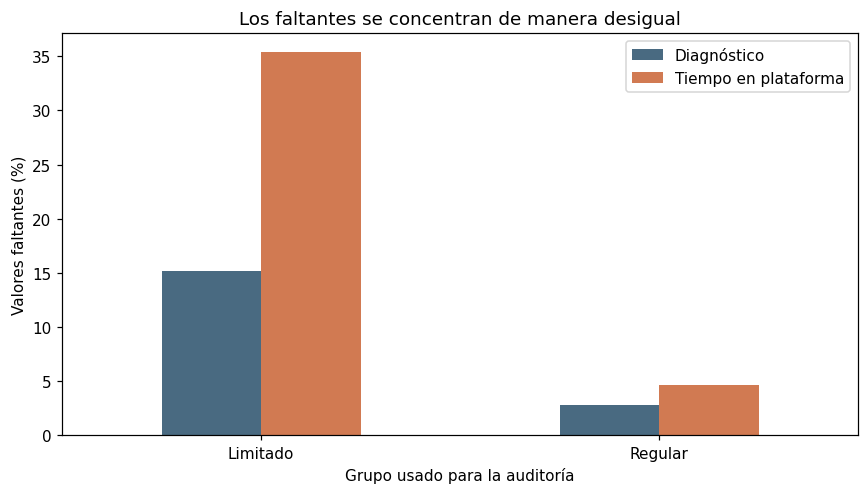

In [5]:
ax = (
    faltantes_por_grupo
    .mul(100)
    .plot(
        kind="bar",
        figsize=(8, 4.6),
        color=["#496A81", "#D17A52"],
    )
)
ax.set_title("Los faltantes se concentran de manera desigual")
ax.set_xlabel("Grupo usado para la auditoría")
ax.set_ylabel("Valores faltantes (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Diagnóstico", "Tiempo en plataforma"])
plt.tight_layout()
plt.show()


Imputar permitirá que el pipeline procese las filas, pero no corregirá el origen desigual de los faltantes. Antes de hacerlo, comprobaremos qué ocurriría si aplicáramos una solución aparentemente simple: eliminar todas las filas incompletas.

En los datos generados, falta el tiempo de plataforma en aproximadamente el **35,4%** de los casos con acceso limitado y en el **4,7%** de los casos con acceso regular. El diagnóstico también falta de manera desigual: **15,2%** frente a **2,8%**.


In [6]:
representacion_antes = (
    estudiantes["grupo_acceso"]
    .value_counts(normalize=True)
    .rename("antes_de_eliminar")
)
representacion_despues = (
    estudiantes
    .dropna()
    ["grupo_acceso"]
    .value_counts(normalize=True)
    .rename("despues_de_eliminar")
)

comparacion_eliminacion = (
    pd.concat([representacion_antes, representacion_despues], axis=1)
    .mul(100)
)

filas_eliminadas = len(estudiantes) - len(estudiantes.dropna())
print(f"Filas eliminadas: {filas_eliminadas:,}")
comparacion_eliminacion


Filas eliminadas: 1,475


,antes_de_eliminar,despues_de_eliminar
grupo_acceso,,
Regular,75.811,84.013
Limitado,24.189,15.987


La eliminación no solo reduce el conjunto: también cambia quiénes permanecen en él. Como los faltantes están concentrados, el grupo con acceso limitado pierde proporcionalmente más casos.

En concreto, se eliminan 1.475 filas y la representación de ese grupo baja del **24,2%** al **16,0%**.

Este resultado no significa que imputar sea automáticamente justo. Significa que la decisión técnica debe evaluarse junto con el proceso que produjo los datos.


## 4. Separar una evaluación de auditoría

Reservaremos 2.000 casos para evaluar. Esta separación se realiza antes de construir las muestras de entrenamiento.

Después prepararemos dos versiones del entrenamiento:

- una muestra **histórica**, donde los casos con acceso limitado quedan fuertemente subrepresentados;
- una muestra **más representativa**, tomada sin esa selección desigual.

Ambos modelos se evaluarán sobre exactamente el mismo conjunto de auditoría.


In [7]:
estratos = (
    estudiantes[["grupo_acceso", "necesita_apoyo"]]
    .astype(str)
    .agg("_".join, axis=1)
)

pool_entrenamiento, auditoria = train_test_split(
    estudiantes,
    test_size=2_000,
    random_state=29,
    stratify=estratos,
)

pesos_seleccion_historica = np.where(
    pool_entrenamiento["grupo_acceso"].eq("Limitado"),
    0.22,
    1.00,
)

muestra_historica = pool_entrenamiento.sample(
    n=3_800,
    weights=pesos_seleccion_historica,
    random_state=29,
)
muestra_representativa = pool_entrenamiento.sample(
    n=3_800,
    random_state=30,
)

def proporcion_limitada(tabla):
    return tabla["grupo_acceso"].eq("Limitado").mean()

representacion = pd.DataFrame({
    "conjunto": [
        "Poblacion simulada",
        "Entrenamiento historico",
        "Entrenamiento representativo",
        "Auditoria",
    ],
    "proporcion_acceso_limitado": [
        proporcion_limitada(estudiantes),
        proporcion_limitada(muestra_historica),
        proporcion_limitada(muestra_representativa),
        proporcion_limitada(auditoria),
    ],
})

representacion


,conjunto,proporcion_acceso_limitado
0,Poblacion simulada,0.242
1,Entrenamiento historico,0.091
2,Entrenamiento representativo,0.237
3,Auditoria,0.242


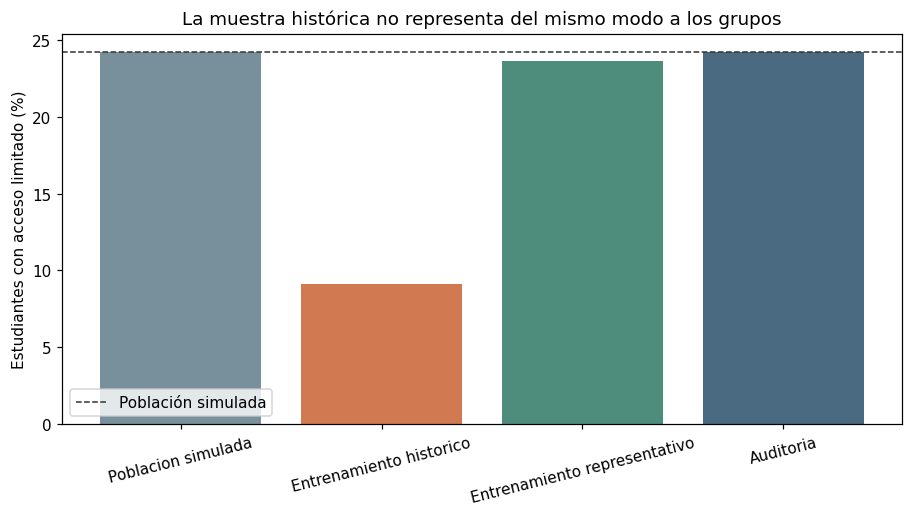

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
colores = ["#78909C", "#D17A52", "#4E8D7C", "#496A81"]

ax.bar(
    representacion["conjunto"],
    representacion["proporcion_acceso_limitado"] * 100,
    color=colores,
)
ax.axhline(
    representacion.loc[0, "proporcion_acceso_limitado"] * 100,
    color="#333333",
    linestyle="--",
    linewidth=1,
    label="Población simulada",
)
ax.set_title("La muestra histórica no representa del mismo modo a los grupos")
ax.set_ylabel("Estudiantes con acceso limitado (%)")
ax.tick_params(axis="x", rotation=14)
ax.legend()
plt.tight_layout()
plt.show()


La subrepresentación no se descubre mirando únicamente el tamaño del dataset. Hay que comparar la composición de los datos de entrenamiento con la población o el contexto donde se pretende aplicar el modelo.

La población simulada y la auditoría contienen alrededor de **24,2%** de estudiantes con acceso limitado. La muestra histórica reduce esa proporción a **9,1%**, mientras que la muestra más representativa conserva aproximadamente **23,7%**.


## 5. Comprobar que la etiqueta histórica no es una verdad perfecta

En aprendizaje supervisado, `y` puede provenir de una decisión administrativa o humana. Simularemos una columna `derivacion_historica`: intenta registrar necesidad de apoyo, pero también está influida por la baja actividad visible.

El objetivo no es decidir cuál etiqueta sería correcta en la realidad. Queremos observar que dos definiciones razonables pueden no coincidir y que entrenar con decisiones anteriores implica aprender sus criterios y errores.


In [9]:
probabilidad_derivacion = np.clip(
    0.07
    + 0.70 * estudiantes["necesita_apoyo"]
    + 0.20 * (estudiantes["accesos_semana"] <= 5),
    0,
    0.95,
)
estudiantes["derivacion_historica"] = generador.binomial(
    1,
    probabilidad_derivacion,
)

comparacion_etiquetas = pd.crosstab(
    estudiantes["necesita_apoyo"],
    estudiantes["derivacion_historica"],
    rownames=["necesidad_simulada"],
    colnames=["derivacion_historica"],
    margins=True,
)

desacuerdo = (
    estudiantes["necesita_apoyo"]
    != estudiantes["derivacion_historica"]
).mean()

print(f"Proporción de desacuerdo: {desacuerdo:.3f}")
comparacion_etiquetas


Proporción de desacuerdo: 0.126


derivacion_historica,0,1,All
necesidad_simulada,,,
0,5167,530,5697
1,604,2699,3303
All,5771,3229,9000


La tabla muestra que una etiqueta histórica puede contener señal y, al mismo tiempo, no coincidir con aquello que hoy queremos modelar. Un modelo que reprodujera perfectamente `derivacion_historica` reproduciría esa decisión registrada; no demostraría que aprendió una verdad objetiva.

Para el resto del cuaderno usaremos `necesita_apoyo`, cuya generación conocemos. Aun así, la trataremos como un indicador didáctico y no como una descripción completa de una persona.


## 6. Preparar un modelo sin usar el grupo de auditoría

El modelo recibirá variables académicas y de actividad. `grupo_acceso` quedará fuera de `X`: se conservará únicamente para comparar el desempeño.

Las columnas numéricas se imputarán con la mediana y se estandarizarán. Las categóricas se imputarán y se codificarán mediante One-Hot Encoding. Todo ocurrirá dentro de un pipeline para que las transformaciones se aprendan solo con entrenamiento.


In [10]:
objetivo = "necesita_apoyo"
columna_auditoria = "grupo_acceso"

variables_numericas = [
    "puntaje_diagnostico",
    "promedio_previo",
    "faltas",
    "accesos_semana",
    "tiempo_plataforma_min",
    "actividades_entregadas",
    "participaciones_foro",
]
variables_categoricas = [
    "dispositivo_compartido",
    "canal_principal",
]
variables_modelo = variables_numericas + variables_categoricas

preprocesamiento = ColumnTransformer([
    (
        "numericas",
        Pipeline([
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", StandardScaler()),
        ]),
        variables_numericas,
    ),
    (
        "categoricas",
        Pipeline([
            ("imputador", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="if_binary",
                ),
            ),
        ]),
        variables_categoricas,
    ),
])

def crear_modelo():
    return Pipeline([
        ("preprocesamiento", preprocesamiento),
        (
            "modelo",
            LogisticRegression(max_iter=2_000, random_state=29),
        ),
    ])

modelo_historico = crear_modelo()
modelo_historico.fit(
    muestra_historica[variables_modelo],
    muestra_historica[objetivo],
)

probabilidad_historica = modelo_historico.predict_proba(
    auditoria[variables_modelo]
)[:, 1]
prediccion_historica = (probabilidad_historica >= 0.50).astype(int)

print("Variables usadas por el modelo:")
print(variables_modelo)
print("\nVariable reservada para auditar:")
print(columna_auditoria)


Variables usadas por el modelo:
['puntaje_diagnostico', 'promedio_previo', 'faltas', 'accesos_semana', 'tiempo_plataforma_min', 'actividades_entregadas', 'participaciones_foro', 'dispositivo_compartido', 'canal_principal']

Variable reservada para auditar:
grupo_acceso


Excluir `grupo_acceso` evita que el modelo use directamente esa columna, pero no garantiza que sus resultados sean iguales entre grupos. `dispositivo_compartido`, `canal_principal` y las mediciones de actividad están relacionadas con las condiciones de acceso y pueden funcionar como señales indirectas o proxies.


## 7. Crear una función de auditoría por subgrupo

Además de las métricas habituales, calcularemos:

- **tasa de predicciones positivas**: proporción de casos enviados a revisión;
- **tasa de falsos positivos**: proporción de estudiantes que no necesitaban apoyo en la simulación, pero fueron señalados;
- cantidad de falsos positivos y falsos negativos.

Estas medidas no definen por sí solas qué sistema es justo. Ayudan a encontrar diferencias que requieren explicación.


In [11]:
def calcular_metricas(y_real, y_predicha):
    tn, fp, fn, tp = confusion_matrix(
        y_real,
        y_predicha,
        labels=[0, 1],
    ).ravel()

    return {
        "casos": len(y_real),
        "prevalencia": y_real.mean(),
        "tasa_predicha": y_predicha.mean(),
        "accuracy": accuracy_score(y_real, y_predicha),
        "precision": precision_score(
            y_real, y_predicha, zero_division=0
        ),
        "recall": recall_score(
            y_real, y_predicha, zero_division=0
        ),
        "f1": f1_score(
            y_real, y_predicha, zero_division=0
        ),
        "tasa_falsos_positivos": fp / (fp + tn),
        "falsos_positivos": fp,
        "falsos_negativos": fn,
    }


def auditar_por_grupo(tabla, probabilidades, umbral=0.50):
    predicciones = (probabilidades >= umbral).astype(int)
    filas = []

    filas.append({
        "grupo": "Total",
        **calcular_metricas(tabla[objetivo], predicciones),
    })

    for grupo in ["Regular", "Limitado"]:
        mascara = tabla[columna_auditoria].eq(grupo).to_numpy()
        filas.append({
            "grupo": grupo,
            **calcular_metricas(
                tabla.loc[mascara, objetivo],
                predicciones[mascara],
            ),
        })

    return pd.DataFrame(filas).set_index("grupo")


auditoria_historica = auditar_por_grupo(
    auditoria,
    probabilidad_historica,
)
auditoria_historica


,casos,prevalencia,tasa_predicha,accuracy,precision,recall,f1,tasa_falsos_positivos,falsos_positivos,falsos_negativos
grupo,,,,,,,,,,
Total,2000,0.367,0.352,0.814,0.757,0.726,0.741,0.135,171,201
Regular,1516,0.366,0.331,0.815,0.773,0.699,0.734,0.119,114,167
Limitado,484,0.370,0.417,0.812,0.718,0.810,0.761,0.187,57,34


La métrica global resume los 2.000 casos, pero oculta diferencias. El modelo alcanza F1 global `0,741`; sin embargo, el recall es `0,699` en acceso regular y `0,810` en acceso limitado. La tasa de falsos positivos cambia de `0,119` a `0,187`.

Por eso no debemos reemplazar la métrica general por una sola métrica de subgrupo: conviene leer ambas miradas.


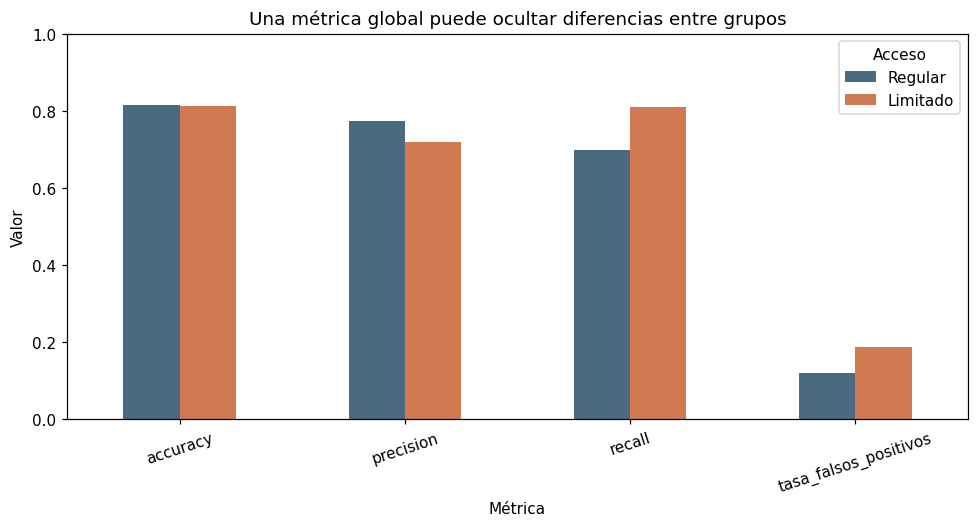

In [12]:
metricas_grafico = [
    "accuracy",
    "precision",
    "recall",
    "tasa_falsos_positivos",
]

ax = (
    auditoria_historica
    .loc[["Regular", "Limitado"], metricas_grafico]
    .T
    .plot(
        kind="bar",
        figsize=(9, 4.9),
        color=["#496A81", "#D17A52"],
    )
)
ax.set_title("Una métrica global puede ocultar diferencias entre grupos")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=18)
ax.legend(title="Acceso")
plt.tight_layout()
plt.show()


En esta simulación, la necesidad real tiene una prevalencia parecida entre los grupos. Sin embargo, el modelo señala una proporción mayor de estudiantes con acceso limitado. La tasa de falsos positivos también resulta mayor en ese grupo.

No podemos concluir automáticamente que una diferencia sea discriminación ni imponer que todas las métricas deban coincidir. Sí podemos concluir que el promedio no cuenta toda la historia y que la diferencia debe investigarse.


## 8. Comparar con un entrenamiento más representativo

Entrenaremos el mismo pipeline con la muestra más representativa. No cambiaremos algoritmo, variables, umbral ni evaluación. Así aislaremos el efecto de la composición del entrenamiento.


In [13]:
modelo_representativo = crear_modelo()
modelo_representativo.fit(
    muestra_representativa[variables_modelo],
    muestra_representativa[objetivo],
)

probabilidad_representativa = modelo_representativo.predict_proba(
    auditoria[variables_modelo]
)[:, 1]

auditoria_representativa = auditar_por_grupo(
    auditoria,
    probabilidad_representativa,
)

comparacion_modelos = pd.concat(
    {
        "Entrenamiento historico": auditoria_historica,
        "Entrenamiento representativo": auditoria_representativa,
    },
    names=["modelo", "grupo"],
)

comparacion_modelos[
    [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "tasa_falsos_positivos",
        "tasa_predicha",
    ]
]


accuracy  precision  recall    f1  \
modelo                       grupo                                         
Entrenamiento historico      Total        0.814      0.757   0.726 0.741   
                             Regular      0.815      0.773   0.699 0.734   
                             Limitado     0.812      0.718   0.810 0.761   
Entrenamiento representativo Total        0.814      0.776   0.691 0.731   
                             Regular      0.810      0.779   0.672 0.721   
                             Limitado     0.824      0.770   0.749 0.759   

                                       tasa_falsos_positivos  tasa_predicha  
modelo                       grupo                                           
Entrenamiento historico      Total                     0.135          0.352  
                             Regular                   0.119          0.331  
                             Limitado                  0.187          0.417  
Entrenamiento representativo Total                     0.115          0.327  
                             Regular                   0.110          0.316  
                             Limitado                  0.131          0.360

,brecha_recall,brecha_falsos_positivos,f1_total
entrenamiento,,,
Histórico,0.111,0.068,0.741
Más representativo,0.077,0.021,0.731


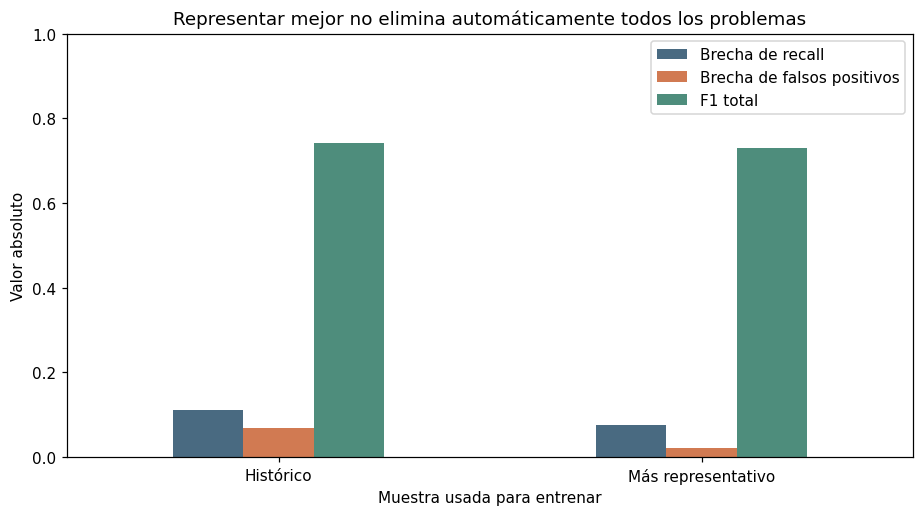

In [14]:
comparacion_brechas = []

for nombre, tabla in [
    ("Histórico", auditoria_historica),
    ("Más representativo", auditoria_representativa),
]:
    comparacion_brechas.append({
        "entrenamiento": nombre,
        "brecha_recall": abs(
            tabla.loc["Regular", "recall"]
            - tabla.loc["Limitado", "recall"]
        ),
        "brecha_falsos_positivos": abs(
            tabla.loc["Regular", "tasa_falsos_positivos"]
            - tabla.loc["Limitado", "tasa_falsos_positivos"]
        ),
        "f1_total": tabla.loc["Total", "f1"],
    })

brechas = pd.DataFrame(comparacion_brechas).set_index("entrenamiento")

ax = brechas.plot(
    kind="bar",
    figsize=(8.5, 4.8),
    color=["#496A81", "#D17A52", "#4E8D7C"],
)
ax.set_title("Representar mejor no elimina automáticamente todos los problemas")
ax.set_xlabel("Muestra usada para entrenar")
ax.set_ylabel("Valor absoluto")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend([
    "Brecha de recall",
    "Brecha de falsos positivos",
    "F1 total",
])
plt.tight_layout()
plt.show()

brechas


La muestra más representativa reduce algunas diferencias sin producir una mejora automática en todas las métricas. Esto es importante: no existe una corrección única que resuelva el problema completo.

La brecha absoluta de falsos positivos baja de `0,068` a `0,021`, y la brecha de recall, de `0,111` a `0,077`. Al mismo tiempo, el F1 global pasa de `0,741` a `0,731`. No elegiremos un modelo solo porque una cifra sea mayor: estamos examinando intercambios y límites.

La representación es una parte de la auditoría. También siguen importando la medición desigual, los faltantes, las variables elegidas, el objetivo y el umbral.


## 9. Reconocer variables proxy

Aunque `grupo_acceso` no forma parte de `X`, varias columnas están asociadas con él. Observaremos proporciones y promedios sin entrenar un modelo adicional.


In [15]:
proxies_categoricos = pd.DataFrame({
    "dispositivo_compartido": (
        estudiantes
        .groupby("grupo_acceso")["dispositivo_compartido"]
        .apply(lambda serie: serie.eq("Si").mean())
    ),
    "canal_movil": (
        estudiantes
        .groupby("grupo_acceso")["canal_principal"]
        .apply(lambda serie: serie.eq("Movil").mean())
    ),
})

actividad_por_grupo = (
    estudiantes
    .groupby("grupo_acceso")[
        [
            "accesos_semana",
            "tiempo_plataforma_min",
            "actividades_entregadas",
        ]
    ]
    .mean()
)

print("Proporciones relacionadas con el acceso:")
print(proxies_categoricos.to_string())
print("\nActividad media registrada:")
actividad_por_grupo


Proporciones relacionadas con el acceso:
              dispositivo_compartido  canal_movil
grupo_acceso                                     
Limitado                       0.665        0.572
Regular                        0.097        0.132

Actividad media registrada:


,accesos_semana,tiempo_plataforma_min,actividades_entregadas
grupo_acceso,,,
Limitado,5.178,113.754,6.388
Regular,10.772,233.245,7.371


Las asociaciones son fuertes porque fueron incorporadas deliberadamente al generador. En datos reales no conoceríamos el mecanismo con esta claridad.

Quitar el nombre de una condición sensible no borra la información relacionada que aparece en otras columnas. A la vez, eliminar todas esas variables puede reducir información útil o introducir nuevos problemas. La decisión requiere contexto, revisión del dominio y, cuando corresponda, criterios legales y éticos.


## 10. Analizar el umbral como una decisión

La regresión logística produce probabilidades. El umbral de `0.50` no es una ley natural: convierte una puntuación en una acción. Compararemos varios valores para observar cómo cambian el recall, los falsos positivos y la cantidad de estudiantes enviados a revisión.


In [16]:
umbrales = np.arange(0.20, 0.81, 0.05)
filas_umbrales = []

for umbral in umbrales:
    tabla = auditar_por_grupo(
        auditoria,
        probabilidad_representativa,
        umbral=umbral,
    )
    filas_umbrales.append({
        "umbral": umbral,
        "recall_total": tabla.loc["Total", "recall"],
        "recall_regular": tabla.loc["Regular", "recall"],
        "recall_limitado": tabla.loc["Limitado", "recall"],
        "fpr_total": tabla.loc[
            "Total", "tasa_falsos_positivos"
        ],
        "tasa_revision": tabla.loc["Total", "tasa_predicha"],
    })

curva_umbrales = pd.DataFrame(filas_umbrales)
curva_umbrales


,umbral,recall_total,recall_regular,recall_limitado,fpr_total,tasa_revision
0,0.200,0.901,0.886,0.944,0.358,0.557
1,0.250,0.876,0.863,0.916,0.299,0.511
2,0.300,0.845,0.829,0.894,0.251,0.469
3,0.350,0.808,0.795,0.849,0.209,0.429
4,0.400,0.783,0.769,0.827,0.176,0.399
5,0.450,0.740,0.721,0.799,0.145,0.363
6,0.500,0.691,0.672,0.749,0.115,0.327
7,0.550,0.651,0.629,0.721,0.091,0.296
8,0.600,0.608,0.580,0.693,0.076,0.271
9,0.650,0.552,0.528,0.626,0.058,0.239


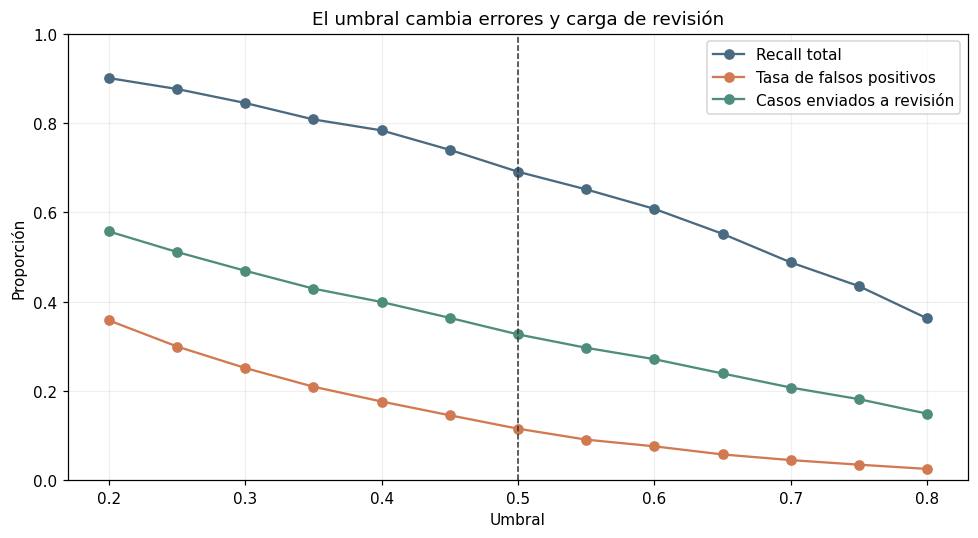

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    curva_umbrales["umbral"],
    curva_umbrales["recall_total"],
    marker="o",
    label="Recall total",
    color="#496A81",
)
ax.plot(
    curva_umbrales["umbral"],
    curva_umbrales["fpr_total"],
    marker="o",
    label="Tasa de falsos positivos",
    color="#D17A52",
)
ax.plot(
    curva_umbrales["umbral"],
    curva_umbrales["tasa_revision"],
    marker="o",
    label="Casos enviados a revisión",
    color="#4E8D7C",
)
ax.axvline(0.50, color="#333333", linestyle="--", linewidth=1)
ax.set_title("El umbral cambia errores y carga de revisión")
ax.set_xlabel("Umbral")
ax.set_ylabel("Proporción")
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


In [18]:
umbrales_seleccionados = []

for umbral in [0.35, 0.50, 0.65]:
    tabla = auditar_por_grupo(
        auditoria,
        probabilidad_representativa,
        umbral=umbral,
    )
    umbrales_seleccionados.append({
        "umbral": umbral,
        "casos_a_revisar": int(
            tabla.loc["Total", "tasa_predicha"] * len(auditoria)
        ),
        "falsos_positivos": int(
            tabla.loc["Total", "falsos_positivos"]
        ),
        "falsos_negativos": int(
            tabla.loc["Total", "falsos_negativos"]
        ),
        "recall_regular": tabla.loc["Regular", "recall"],
        "recall_limitado": tabla.loc["Limitado", "recall"],
    })

pd.DataFrame(umbrales_seleccionados).set_index("umbral")


,casos_a_revisar,falsos_positivos,falsos_negativos,recall_regular,recall_limitado
umbral,,,,,
0.350,858,265,141,0.795,0.849
0.500,653,146,227,0.672,0.749
0.650,478,73,329,0.528,0.626


Un umbral bajo detecta más casos que requieren apoyo, pero también aumenta las alertas incorrectas y la carga de revisión. Un umbral alto reduce revisiones, pero deja más necesidades sin detectar.

En este ejemplo, bajar el umbral a `0,35` envía 858 casos a revisión, con 265 falsos positivos y 141 falsos negativos. Subirlo a `0,65` reduce las revisiones a 478 y los falsos positivos a 73, pero aumenta los falsos negativos a 329.

La elección no debería hacerse solo para maximizar una métrica. Requiere conocer las consecuencias de cada error, la capacidad real de revisión y qué ocurre después de que una persona es señalada.


## 11. Diferenciar correlación y causalidad

En la simulación sabemos que el acceso limitado reduce la actividad registrada, pero no participa directamente en la generación de `necesita_apoyo`. Compararemos ambos grupos para ver por qué una asociación útil para predecir no prueba una causa.


,necesidad_media,accesos_medios,tiempo_medio
grupo_acceso,,,
Limitado,0.370,5.178,113.754
Regular,0.366,10.772,233.245


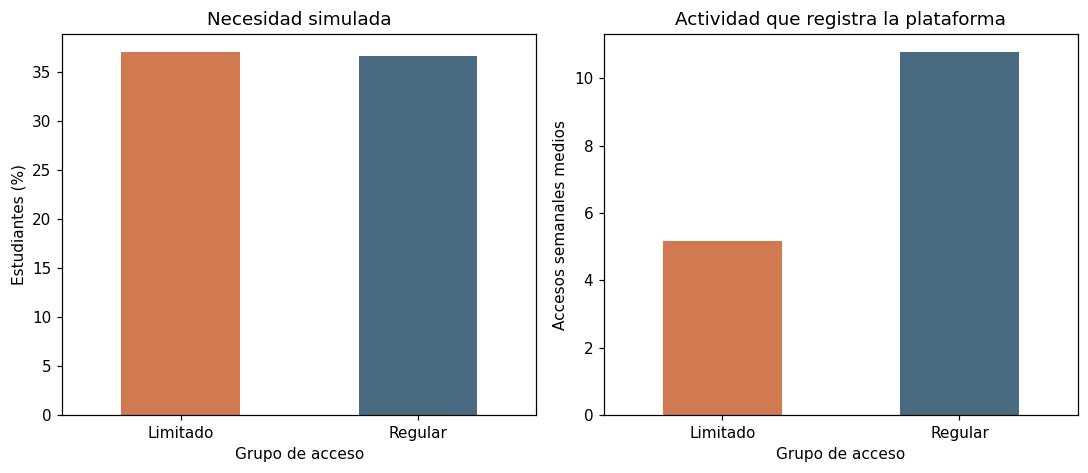

In [19]:
resumen_asociaciones = (
    estudiantes
    .groupby("grupo_acceso")
    .agg(
        necesidad_media=("necesita_apoyo", "mean"),
        accesos_medios=("accesos_semana", "mean"),
        tiempo_medio=("tiempo_plataforma_min", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))

resumen_asociaciones["necesidad_media"].mul(100).plot(
    kind="bar",
    ax=axes[0],
    color=["#D17A52", "#496A81"],
)
axes[0].set_title("Necesidad simulada")
axes[0].set_ylabel("Estudiantes (%)")
axes[0].set_xlabel("Grupo de acceso")
axes[0].tick_params(axis="x", rotation=0)

resumen_asociaciones["accesos_medios"].plot(
    kind="bar",
    ax=axes[1],
    color=["#D17A52", "#496A81"],
)
axes[1].set_title("Actividad que registra la plataforma")
axes[1].set_ylabel("Accesos semanales medios")
axes[1].set_xlabel("Grupo de acceso")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

resumen_asociaciones


La plataforma registra menos accesos en un grupo aunque la prevalencia de necesidad simulada sea muy parecida. Si interpretáramos “menos accesos” como “menos compromiso” o como causa directa de dificultad, iríamos más allá de lo que los datos demuestran.

La necesidad simulada aparece en aproximadamente el **37,0%** del grupo con acceso limitado y el **36,6%** del grupo regular. En cambio, la plataforma registra en promedio **5,18** y **10,77** accesos semanales, respectivamente.

El modelo puede usar una variable como señal predictiva. Eso no implica que intervenir sobre esa señal vaya a producir el resultado deseado.


## 12. Traducir predicciones a consecuencias

Imaginemos que una predicción positiva no produce una sanción ni una decisión final: abre una revisión humana. Incluso en ese escenario prudente, debemos definir qué revisará la persona, con qué información y qué posibilidad habrá de corregir datos.

Construiremos un registro de auditoría para el umbral `0.50`. No mostraremos nombres ni identificadores personales: cada fila representa solo un caso sintético.


In [20]:
umbral_operativo = 0.50
prediccion_operativa = (
    probabilidad_representativa >= umbral_operativo
).astype(int)

registro_auditoria = auditoria[
    [
        "grupo_acceso",
        "necesita_apoyo",
        "accesos_semana",
        "tiempo_plataforma_min",
        "dispositivo_compartido",
    ]
].copy()
registro_auditoria["probabilidad_modelo"] = (
    probabilidad_representativa
)
registro_auditoria["enviado_a_revision"] = prediccion_operativa
registro_auditoria["tipo_resultado"] = np.select(
    [
        (registro_auditoria["necesita_apoyo"] == 1)
        & (registro_auditoria["enviado_a_revision"] == 1),
        (registro_auditoria["necesita_apoyo"] == 0)
        & (registro_auditoria["enviado_a_revision"] == 1),
        (registro_auditoria["necesita_apoyo"] == 1)
        & (registro_auditoria["enviado_a_revision"] == 0),
    ],
    ["verdadero_positivo", "falso_positivo", "falso_negativo"],
    default="verdadero_negativo",
)

(
    registro_auditoria["tipo_resultado"]
    .value_counts()
    .to_frame("cantidad")
)


,cantidad
tipo_resultado,
verdadero_negativo,1120
verdadero_positivo,507
falso_negativo,227
falso_positivo,146


In [21]:
ejemplos_para_revision = pd.concat([
    registro_auditoria.query(
        "tipo_resultado == 'falso_positivo'"
    ).head(3),
    registro_auditoria.query(
        "tipo_resultado == 'falso_negativo'"
    ).head(3),
])

ejemplos_para_revision


,grupo_acceso,necesita_apoyo,accesos_semana,tiempo_plataforma_min,dispositivo_compartido,probabilidad_modelo,enviado_a_revision,tipo_resultado
1295,Limitado,0,0,44.800,Si,0.750,1,falso_positivo
6563,Regular,0,15,311.800,No,0.589,1,falso_positivo
4514,Limitado,0,5,202.400,No,0.894,1,falso_positivo
7351,Limitado,1,7,164.600,No,0.305,0,falso_negativo
92,Regular,1,10,263.000,No,0.019,0,falso_negativo
5546,Regular,1,16,257.000,No,0.162,0,falso_negativo


Las filas no explican por sí solas por qué ocurrió cada error. Funcionan como punto de partida para revisar calidad de datos, contexto de acceso y señales utilizadas.

En un sistema real, una persona debería poder cuestionar la salida, consultar información relevante, registrar la corrección y evitar que la puntuación sea comunicada como una certeza.


## 13. Documentar antes de usar

Una ficha breve no reemplaza una documentación completa, pero obliga a dejar por escrito el propósito, los datos, las métricas y los límites. Aquí construimos una versión mínima a partir de los resultados reales del cuaderno.


In [22]:
ficha_modelo = pd.DataFrame({
    "aspecto": [
        "Propósito didáctico",
        "Datos",
        "Objetivo",
        "Variable solo para auditoría",
        "F1 global",
        "Recall por acceso",
        "Uso permitido",
        "Uso no permitido",
        "Limitaciones principales",
        "Revisión necesaria",
    ],
    "registro": [
        "Estudiar sesgos y decisiones; no decidir sobre estudiantes reales",
        "Población sintética con actividad, desempeño y acceso",
        "Indicador simulado de necesidad de apoyo",
        "grupo_acceso",
        f"{auditoria_representativa.loc['Total', 'f1']:.3f}",
        (
            f"Regular: "
            f"{auditoria_representativa.loc['Regular', 'recall']:.3f}; "
            f"Limitado: "
            f"{auditoria_representativa.loc['Limitado', 'recall']:.3f}"
        ),
        "Ejercicio educativo y auditoría del flujo",
        "Sancionar, excluir, calificar o automatizar intervenciones",
        (
            "Datos simulados, medición desigual, faltantes y proxies; "
            "sin evidencia causal"
        ),
        "Humana, por subgrupos y durante todo el ciclo de uso",
    ],
})

ficha_modelo


,aspecto,registro
0,Propósito didáctico,Estudiar sesgos y decisiones; no decidir sobre...
1,Datos,"Población sintética con actividad, desempeño y..."
2,Objetivo,Indicador simulado de necesidad de apoyo
3,Variable solo para auditoría,grupo_acceso
4,F1 global,0.731
5,Recall por acceso,Regular: 0.672; Limitado: 0.749
6,Uso permitido,Ejercicio educativo y auditoría del flujo
7,Uso no permitido,"Sancionar, excluir, calificar o automatizar in..."
8,Limitaciones principales,"Datos simulados, medición desigual, faltantes ..."
9,Revisión necesaria,"Humana, por subgrupos y durante todo el ciclo ..."


## 14. Actividad modificable

El bloque siguiente permite cambiar el umbral y repetir la auditoría. Probá, por ejemplo, `0.35`, `0.50` y `0.65`.

No busques solamente el valor con mejor F1. Observá:

- cuántos casos se enviarían a revisión;
- cuántos falsos positivos y falsos negativos aparecen;
- si el recall cambia de manera similar en ambos grupos;
- si la cantidad de revisiones sería viable;
- qué consecuencias tendría cada error.


In [23]:
umbral_a_probar = 0.50  # Cambiar entre 0 y 1

resultado_actividad = auditar_por_grupo(
    auditoria,
    probabilidad_representativa,
    umbral=umbral_a_probar,
)

columnas_actividad = [
    "casos",
    "tasa_predicha",
    "precision",
    "recall",
    "f1",
    "tasa_falsos_positivos",
    "falsos_positivos",
    "falsos_negativos",
]

resultado_actividad[columnas_actividad]


,casos,tasa_predicha,precision,recall,f1,tasa_falsos_positivos,falsos_positivos,falsos_negativos
grupo,,,,,,,,
Total,2000,0.327,0.776,0.691,0.731,0.115,146,227
Regular,1516,0.316,0.779,0.672,0.721,0.110,106,182
Limitado,484,0.360,0.770,0.749,0.759,0.131,40,45


## 15. Lista de revisión responsable

Antes de convertir predicciones en decisiones, conviene revisar:

1. **Problema:** qué se intenta apoyar y qué no debería automatizarse.
2. **Datos:** quiénes están representados, quiénes faltan y cómo se midió.
3. **Etiqueta:** qué significa realmente `y` y quién la produjo.
4. **Variables:** cuáles son sensibles, contextuales o posibles proxies.
5. **Evaluación:** métricas globales, subgrupos, errores y estabilidad temporal.
6. **Umbral:** costos, capacidad de revisión y consecuencias.
7. **Comunicación:** presentar la salida como estimación, no como certeza.
8. **Supervisión:** permitir comprender, cuestionar y corregir.
9. **Monitoreo:** detectar cambios en datos, métricas y tipos de error.
10. **Retiro:** dejar de usar el modelo si ya no resulta confiable o adecuado.


## 16. Síntesis

En este cuaderno comprobamos que los sesgos pueden aparecer antes, durante y después del entrenamiento:

- la muestra histórica subrepresentó a estudiantes con acceso limitado;
- los valores faltantes se concentraron de manera desigual;
- eliminar filas completas intensificó esa pérdida de representación;
- una decisión histórica no coincidió perfectamente con el indicador que queríamos estudiar;
- variables aparentemente neutrales conservaron información sobre el contexto de acceso;
- el promedio global ocultó diferencias de recall y falsos positivos;
- una muestra más representativa redujo algunas brechas, pero no resolvió todo;
- el umbral cambió los errores y la carga de revisión;
- una asociación predictiva no demostró causalidad;
- documentar, revisar y monitorear siguió siendo responsabilidad humana.

El objetivo de una auditoría no es obtener una etiqueta automática de “modelo justo”. Es reunir evidencia para decidir si el sistema es adecuado, qué riesgos conserva y qué acciones humanas son necesarias.


## Para pensar

1. ¿Por qué eliminar las filas con faltantes redujo especialmente la representación del grupo con acceso limitado?
2. Si `grupo_acceso` no fue usado por el modelo, ¿a través de qué variables podría seguir apareciendo información relacionada?
3. ¿Qué diferencia hay entre reproducir correctamente una derivación histórica y predecir una necesidad real de apoyo?
4. ¿Qué consecuencias tendría bajar el umbral si el equipo solo puede revisar una cantidad limitada de casos?
5. ¿Qué información adicional necesitarías antes de considerar el uso de un modelo semejante en una institución real?
